# 🏥 IUI Prediction - Model Training & XAI (ข้อมูลถึงปี 2567)

In [1]:
import os
if os.getcwd().endswith('src'): os.chdir('..')

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN

import shap
import joblib
import warnings
warnings.filterwarnings('ignore')
print('✅ โหลดไลบรารีสำเร็จ')

✅ โหลดไลบรารีสำเร็จ


### 1. ฟังก์ชันสนับสนุน (Helper Functions)

In [2]:
def clean_column_names(df):
    df.columns = [re.sub(r'[\[\]<>]', '_', str(col)).replace(' ', '_') for col in df.columns]
    return df

def find_optimal_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j_scores = tpr - fpr
    return thresholds[np.argmax(j_scores)]

def calculate_net_benefit(y_true, y_prob, threshold):
    tp = np.logical_and(y_true == 1, y_prob >= threshold).sum()
    fp = np.logical_and(y_true == 0, y_prob >= threshold).sum()
    n = len(y_true)
    if threshold == 1: return 0
    net_benefit = (tp / n) - (fp / n) * (threshold / (1 - threshold))
    return net_benefit

def plot_confusion_matrix(y_true, y_pred, model_name, sampler_name, threshold):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Preg (0)', 'Preg (1)'], yticklabels=['Non-Preg (0)', 'Preg (1)'])
    plt.title(f'Confusion Matrix\n{model_name} + {sampler_name}\n(Threshold: {threshold:.3f})')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'reports_2567/figures/confusion_matrices/{model_name}_{sampler_name}_CM.png')
    plt.close()

def plot_roc_curve(y_true, y_prob, model_name, sampler_name, auc_score, best_threshold):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    best_idx = np.argmin(np.abs(thresholds - best_threshold))
    best_fpr, best_tpr = fpr[best_idx], tpr[best_idx]
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.scatter([best_fpr], [best_tpr], marker='o', color='red', s=100, label=f'Optimal Threshold ({best_threshold:.2f})', zorder=5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve: {model_name} + {sampler_name}')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(f'reports_2567/figures/roc_curves/{model_name}_{sampler_name}_ROC.png')
    plt.close()

### 2. โหลดและเตรียมข้อมูล (ฟิลเตอร์ข้อมูลถึงปี 2567 และคัด Date ออก)

In [3]:
df = pd.read_csv('data/processed/cycle_level_ready_for_ml.csv')
df = clean_column_names(df)

date_col = next((c for c in df.columns if c.lower() == 'date'), None)

if date_col:
    orig_dates = df[date_col].astype(str)
    parsed_dates = pd.to_datetime(orig_dates, errors='coerce')
    if parsed_dates.notna().any():
        df[date_col] = parsed_dates
        df = df.dropna(subset=[date_col])
        df = df[df[date_col].dt.year <= 2567]
    else:
        print("⚠️ ระบบตรวจพบวันที่เป็นปี พ.ศ. (เกินข้อจำกัด Pandas) กำลังใช้ระบบดึงข้อมูลปีแบบสำรอง...")
        years = orig_dates.str.extract(r'((?:19|20|25)\d{2})')[0].astype(float)
        df['temp_year'] = years
        df = df.dropna(subset=['temp_year'])
        df = df[df['temp_year'] <= 2567]
        df = df.drop(columns=['temp_year'])
    print(f"✅ คัดกรองข้อมูลจนถึงปี 2567 สำเร็จแล้ว (เหลือข้อมูล {len(df)} แถว)")
    if len(df) == 0:
        raise ValueError(f"❌ ข้อมูลว่างเปล่า! คอลัมน์ {date_col} ไม่มีข้อมูลที่ตรงเงื่อนไข")
    df = df.drop(columns=[date_col])
else:
    print("⚠️ ไม่พบคอลัมน์ 'Date' ในชุดข้อมูล")

# กวาดล้าง DateTime และ Object
datetime_cols = df.select_dtypes(include=['datetime64', 'datetimetz']).columns
for c in datetime_cols:
    df[c] = pd.to_numeric(df[c].dt.strftime('%Y%m%d'), errors='coerce')
object_cols = df.select_dtypes(include=['object']).columns
for c in object_cols:
    if c not in ['HN', 'Result']:
        df[c] = pd.to_numeric(df[c], errors='coerce')

if 'HN' in df.columns:
    df = df.dropna(subset=['HN'])

X_full = df.drop(['Result'], axis=1, errors='ignore')
y_full = df['Result']
groups = df['HN'] if 'HN' in df.columns else np.arange(len(df))

imputer = SimpleImputer(strategy='median')
cols_to_impute = [c for c in X_full.columns if c != 'HN']
X_imputed = pd.DataFrame(imputer.fit_transform(X_full[cols_to_impute]), columns=cols_to_impute)
if 'HN' in X_full.columns:
    X_imputed['HN'] = X_full['HN'].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_imputed, y_full, groups=groups))
X_train, X_test = X_imputed.iloc[train_idx].copy(), X_imputed.iloc[test_idx].copy()
y_train, y_test = y_full.iloc[train_idx], y_full.iloc[test_idx]

test_info = X_test[['HN', 'Cycle_Number']].copy() if 'Cycle_Number' in X_test.columns else X_test[['HN']].copy()

if 'HN' in X_train.columns:
    X_train, X_test = X_train.drop('HN', axis=1), X_test.drop('HN', axis=1)
print(f'Split done. Train: {len(X_train)}, Test: {len(X_test)}')
print(f"จำนวนคอลัมน์ที่ใช้เทรน (ไม่รวม Date): {X_train.shape[1]} คอลัมน์")

⚠️ ระบบตรวจพบวันที่เป็นปี พ.ศ. (เกินข้อจำกัด Pandas) กำลังใช้ระบบดึงข้อมูลปีแบบสำรอง...
✅ คัดกรองข้อมูลจนถึงปี 2567 สำเร็จแล้ว (เหลือข้อมูล 2691 แถว)
Split done. Train: 2149, Test: 542
จำนวนคอลัมน์ที่ใช้เทรน (ไม่รวม Date): 53 คอลัมน์


### 3. Hyperparameter Tuning & Model Selection

In [4]:
models_params = {
    'CatBoost': {'model': CatBoostClassifier(random_state=42, verbose=0), 'params': {'iterations': [100, 200], 'depth': [4, 6]}},
    'XGBoost': {'model': XGBClassifier(random_state=42, eval_metric='logloss'), 'params': {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1]}},
    'RandomForest': {'model': RandomForestClassifier(random_state=42), 'params': {'n_estimators': [100, 200], 'max_depth': [10, 20]}},
    'MLP': {'model': Pipeline([('scaler', StandardScaler()), ('model', MLPClassifier(random_state=42, max_iter=1000))]), 'params': {'model__hidden_layer_sizes': [(100, 50), (50,)]}}
}
samplers = {'ADASYN': ADASYN(random_state=42), 'SMOTE': SMOTE(random_state=42)}
results_list, trained_models = [], {}

for s_name, sampler in samplers.items():
    X_res, y_res = sampler.fit_resample(X_train, y_train)
    for m_name, mp in models_params.items():
        print(f'Training {m_name} with {s_name}...')
        rs = RandomizedSearchCV(mp['model'], mp['params'], n_iter=4, cv=3, scoring='roc_auc', random_state=42, n_jobs=-1)
        rs.fit(X_res, y_res)
        best_m = rs.best_estimator_
        y_prob = best_m.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
        th = find_optimal_threshold(y_test, y_prob)
        
        y_pred_opt = (y_prob >= th).astype(int)
        acc = accuracy_score(y_test, y_pred_opt)
        prec = precision_score(y_test, y_pred_opt, zero_division=0)
        rec = recall_score(y_test, y_pred_opt, zero_division=0)
        f1 = f1_score(y_test, y_pred_opt, zero_division=0)
        
        results_list.append({'Imbalance': s_name, 'Model': m_name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC-AUC': auc, 'Optimal_Th': th})
        trained_models[f'{m_name}_{s_name}'] = {'model': best_m, 'probs': y_prob}
        
        os.makedirs(f'models_2567/saved_models/{m_name}', exist_ok=True)
        joblib.dump(best_m, f'models_2567/saved_models/{m_name}/{m_name}_{s_name}.joblib')
        plot_confusion_matrix(y_test, y_pred_opt, m_name, s_name, th)
        plot_roc_curve(y_test, y_prob, m_name, s_name, auc, th)

results_df = pd.DataFrame(results_list).sort_values('ROC-AUC', ascending=False)
results_df.to_excel('reports_2567/tables/model_performance_comparison.xlsx', index=False)
print('\n✅ บันทึกตารางเปรียบเทียบโมเดล และไฟล์โมเดลสำเร็จ')
print('Ranking Top 3:')
print(results_df.head(3))

Training CatBoost with ADASYN...
Training XGBoost with ADASYN...
Training RandomForest with ADASYN...
Training MLP with ADASYN...
Training CatBoost with SMOTE...
Training XGBoost with SMOTE...
Training RandomForest with SMOTE...
Training MLP with SMOTE...

✅ บันทึกตารางเปรียบเทียบโมเดล และไฟล์โมเดลสำเร็จ
Ranking Top 3:
  Imbalance         Model  Accuracy  Precision    Recall        F1   ROC-AUC  \
0    ADASYN      CatBoost  0.457565   0.084906  0.900000  0.155172  0.692383   
4     SMOTE      CatBoost  0.457565   0.087500  0.933333  0.160000  0.672526   
6     SMOTE  RandomForest  0.671587   0.097826  0.600000  0.168224  0.648828   

   Optimal_Th  
0    0.029177  
4    0.033995  
6    0.159061  


### 4. Feature Budget Optimization & SHAP XAI
ทำการหาจุดคุ้มทุนแบบพลวัต (Dynamic Cost-Effective Budget) และสร้างกราฟ SHAP ตามจำนวนตัวแปรที่เหมาะสมที่สุด


Calculating Feature Budget AUCs...
🎯 Max AUC = 0.7198 | 💡 Cost-Effective Budget ค้นพบแล้ว! ใช้ 46 ตัวแปร (ROC-AUC = 0.7198)


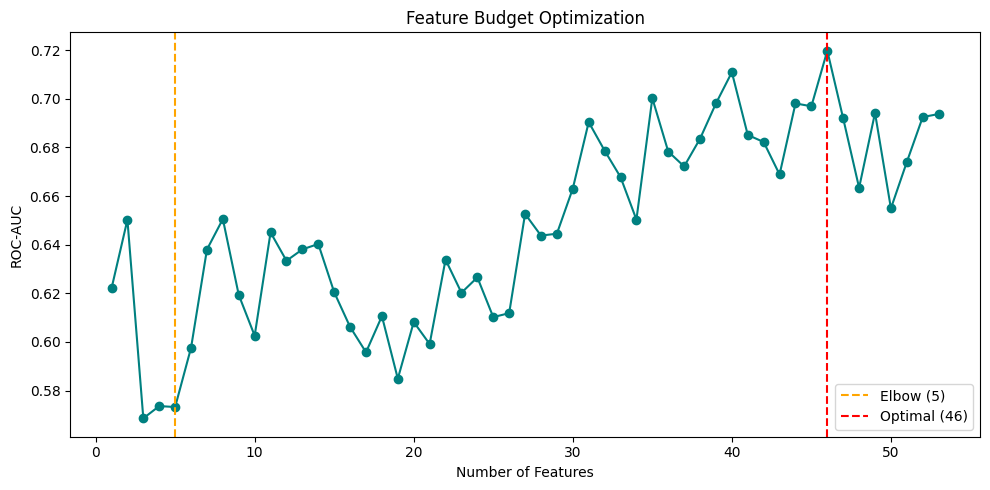

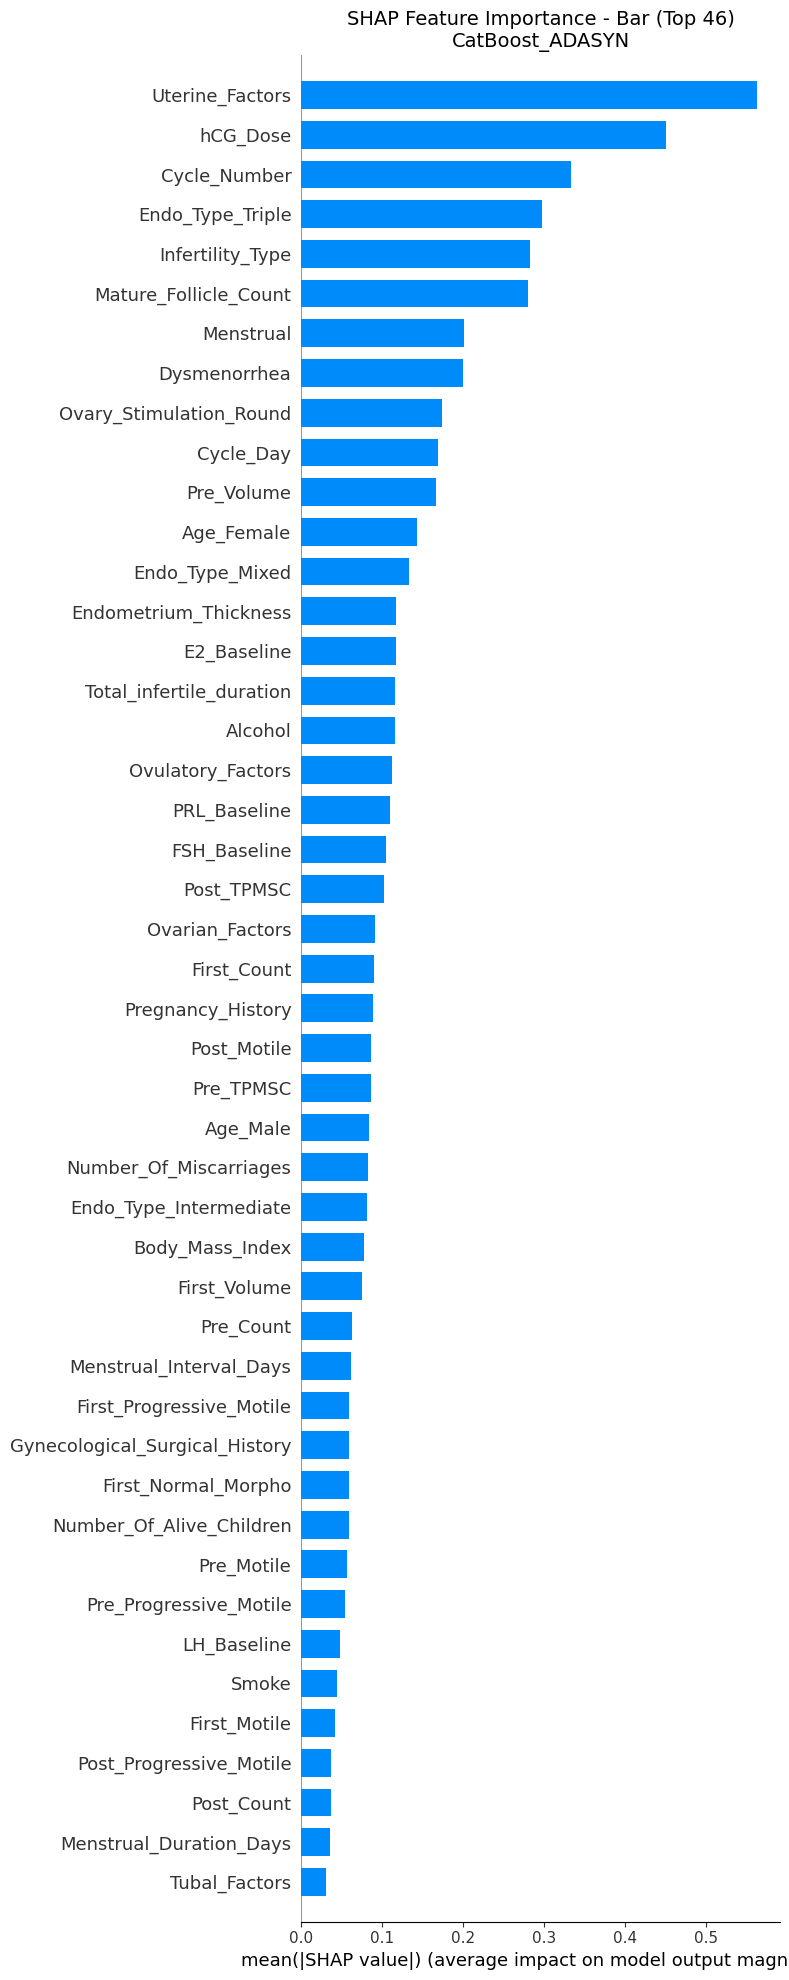

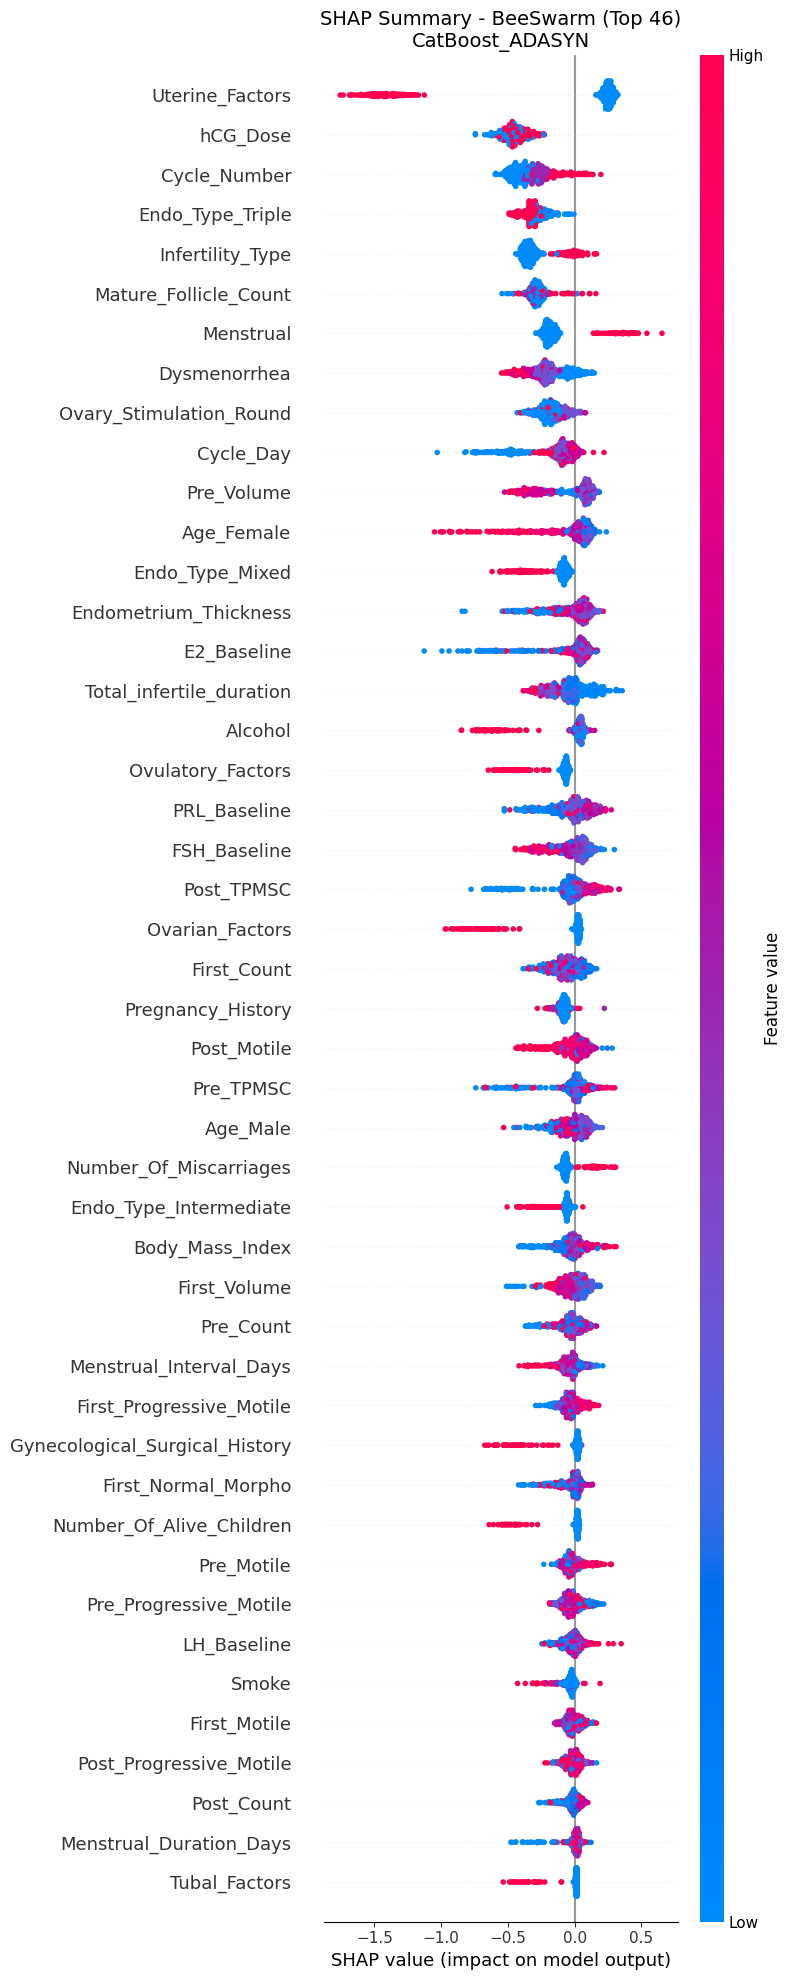


✅ บันทึกโมเดลที่ดีที่สุด (Top 46 Features) และรายชื่อตัวแปร ไว้ที่: models_2567/saved_models/Best_Model/


In [5]:
best_key = f"{results_df.iloc[0]['Model']}_{results_df.iloc[0]['Imbalance']}"
best_model_obj = trained_models[best_key]['model']
explainer = shap.TreeExplainer(best_model_obj) if 'MLP' not in best_key else shap.KernelExplainer(best_model_obj.predict_proba, shap.kmeans(X_train, 10))
shap_v = explainer.shap_values(X_test)
if isinstance(shap_v, list): shap_v = shap_v[1]

feat_imp = pd.DataFrame({'Feature': X_test.columns, 'Importance': np.abs(shap_v).mean(axis=0)}).sort_values('Importance', ascending=False)
feat_imp.to_excel(f"reports_2567/tables/Feature_Budget_{results_df.iloc[0]['Model']}.xlsx", index=False)

# --- 4.1 Feature Budget Optimization ---
print('\nCalculating Feature Budget AUCs...')
top_f = feat_imp['Feature'].tolist()
budget_aucs = []
best_s_name = results_df.iloc[0]['Imbalance']
X_train_res, y_train_res = samplers[best_s_name].fit_resample(X_train, y_train)

for k in range(1, len(top_f) + 1):
    sub_f = top_f[:k]
    if 'MLP' in best_key:
        m_k = Pipeline([('scaler', StandardScaler()), ('model', MLPClassifier(**best_model_obj.named_steps['model'].get_params()))])
    else:
        p_k = best_model_obj.get_params()
        for skip in ['verbose', 'logging_level', 'cat_features']: p_k.pop(skip, None)
        if 'CatBoost' in best_key: m_k = CatBoostClassifier(**p_k, verbose=0)
        elif 'XGBoost' in best_key: m_k = XGBClassifier(**p_k)
        else: m_k = RandomForestClassifier(**p_k)
    m_k.fit(X_train_res[sub_f], y_train_res)
    budget_aucs.append(roc_auc_score(y_test, m_k.predict_proba(X_test[sub_f])[:, 1]))

max_auc = max(budget_aucs)
# คำนวณความคุ้มค่าทางการแพทย์ (Cost-Effectiveness): เลือกจำนวนตัวแปรที่น้อยที่สุดที่ทำ AUC ได้ใกล้เคียงจุดสูงสุด (ดรอปไม่เกิน 0.005)
optimal_k = next(i+1 for i, auc in enumerate(budget_aucs) if auc >= max_auc - 0.005)

print(f"🎯 Max AUC = {max_auc:.4f} | 💡 Cost-Effective Budget ค้นพบแล้ว! ใช้ {optimal_k} ตัวแปร (ROC-AUC = {budget_aucs[optimal_k-1]:.4f})")

plt.figure(figsize=(10,5))
plt.plot(range(1, len(top_f)+1), budget_aucs, marker='o', color='teal')
plt.axvline(x=5, color='orange', linestyle='--', label='Elbow (5)')
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal ({optimal_k})')
plt.title('Feature Budget Optimization')
plt.xlabel('Number of Features')
plt.ylabel('ROC-AUC')
plt.legend()
plt.tight_layout()
plt.savefig('reports_2567/figures/Feature_Budget_Optimization.png')
plt.show()

# --- 4.2 พล็อต SHAP ตามจำนวน Cost-Effective Optimal Feature Budget ---
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_v, X_test, plot_type='bar', max_display=optimal_k, show=False)
plt.title(f'SHAP Feature Importance - Bar (Top {optimal_k})\n{best_key}', fontsize=14)
plt.tight_layout()
plt.savefig(f'reports_2567/figures/shap/SHAP_Bar_Top{optimal_k}.png')
plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_v, X_test, max_display=optimal_k, show=False)
plt.title(f'SHAP Summary - BeeSwarm (Top {optimal_k})\n{best_key}', fontsize=14)
plt.tight_layout()
plt.savefig(f'reports_2567/figures/shap/SHAP_BeeSwarm_Top{optimal_k}.png')
plt.show()

# Train final Optimal model เพื่อไว้ใช้ทำ DCA และจัด Risk Tier
optimal_features = top_f[:optimal_k]
p = best_model_obj.get_params()
for skip in ['verbose', 'logging_level', 'cat_features']: p.pop(skip, None)
final_model_opt = CatBoostClassifier(**p, verbose=0) if 'CatBoost' in best_key else XGBClassifier(**p)
final_model_opt.fit(X_train_res[optimal_features], y_train_res)
final_probs_opt = final_model_opt.predict_proba(X_test[optimal_features])[:, 1]

# --- บันทึกโมเดลที่ดีที่สุดและรายชื่อตัวแปรที่ใช้ ---
os.makedirs(f'models_2567/saved_models/Best_Model', exist_ok=True)
joblib.dump(final_model_opt, f'models_2567/saved_models/Best_Model/Best_Clinical_Model_Top{optimal_k}.joblib')
joblib.dump(optimal_features, f'models_2567/saved_models/Best_Model/Optimal_Features_List.joblib')
print(f"\n✅ บันทึกโมเดลที่ดีที่สุด (Top {optimal_k} Features) และรายชื่อตัวแปร ไว้ที่: models_2567/saved_models/Best_Model/")

### 5. Clinical Analysis 1: Risk Stratification

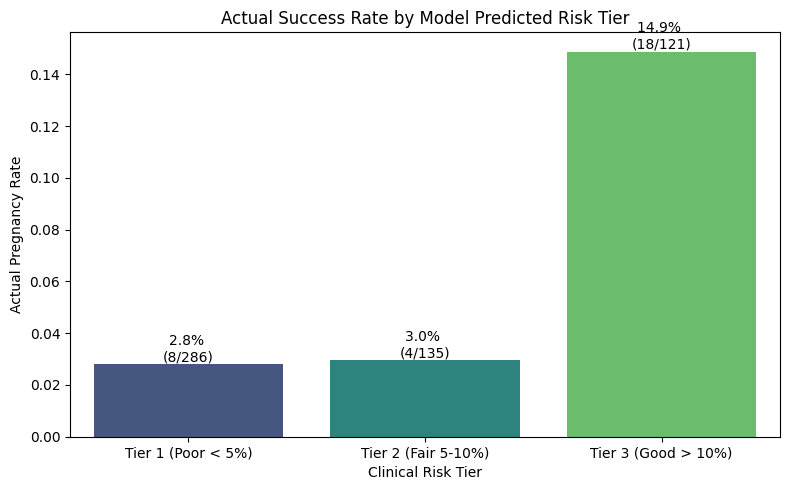

             Risk_Tier  Total_Patients  Actual_Pregnancies  \
0   Tier 1 (Poor < 5%)             286                   8   
1  Tier 2 (Fair 5-10%)             135                   4   
2  Tier 3 (Good > 10%)             121                  18   

   Avg_Predicted_Prob  Actual_Success_Rate  
0            0.019829             0.027972  
1            0.072710             0.029630  
2            0.167232             0.148760  


In [6]:
test_info['Predicted_Prob'] = final_probs_opt
test_info['Actual_Result'] = y_test.values

def assign_tier(prob):
    if prob < 0.05: return 'Tier 1 (Poor < 5%)'
    elif prob < 0.10: return 'Tier 2 (Fair 5-10%)'
    else: return 'Tier 3 (Good > 10%)'

test_info['Risk_Tier'] = test_info['Predicted_Prob'].apply(assign_tier)
tier_summary = test_info.groupby('Risk_Tier').agg(Total_Patients=('HN', 'count'), Actual_Pregnancies=('Actual_Result', 'sum'), Avg_Predicted_Prob=('Predicted_Prob', 'mean')).reset_index()
tier_summary['Actual_Success_Rate'] = tier_summary['Actual_Pregnancies'] / tier_summary['Total_Patients']

tier_summary.to_excel('reports_2567/tables/Risk_Tier_Summary.xlsx', index=False)
plt.figure(figsize=(8,5))
sns.barplot(x='Risk_Tier', y='Actual_Success_Rate', data=tier_summary, palette='viridis')
plt.title('Actual Success Rate by Model Predicted Risk Tier')
plt.ylabel('Actual Pregnancy Rate')
plt.xlabel('Clinical Risk Tier')
for index, row in tier_summary.iterrows():
    plt.text(index, row.Actual_Success_Rate, f"{row.Actual_Success_Rate:.1%} \n({row.Actual_Pregnancies}/{row.Total_Patients})", color='black', ha="center", va="bottom")
plt.tight_layout()
plt.savefig('reports_2567/figures/clinical/Risk_Tier_Analysis.png')
plt.show()
print(tier_summary)

### 6. Clinical Analysis 2: Cumulative Cycle Impact

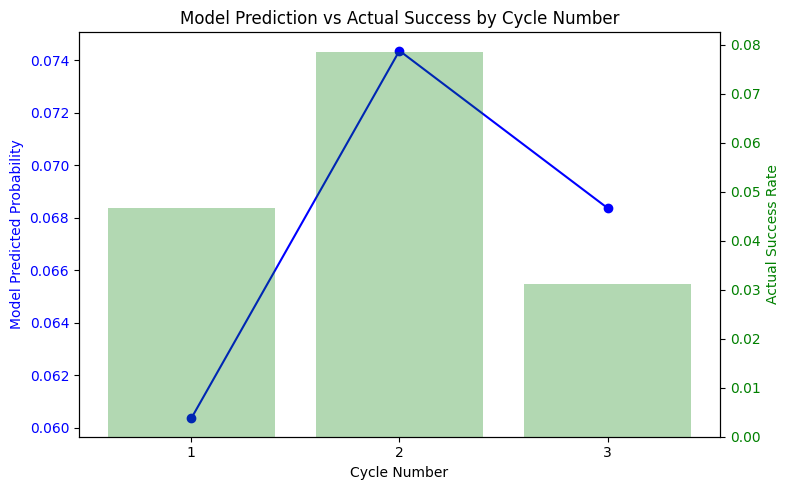

In [7]:
if 'Cycle_Number' in test_info.columns:
    cycle_summary = test_info.groupby('Cycle_Number').agg(Total_Cycles=('HN', 'count'), Avg_Predicted_Prob=('Predicted_Prob', 'mean'), Actual_Pregnancies=('Actual_Result', 'sum')).reset_index()
    cycle_summary['Actual_Success_Rate'] = cycle_summary['Actual_Pregnancies'] / cycle_summary['Total_Cycles']
    cycle_summary = cycle_summary[cycle_summary['Cycle_Number'] <= 3]
    cycle_summary.to_excel('reports_2567/tables/Cumulative_Cycle_Summary.xlsx', index=False)

    fig, ax1 = plt.subplots(figsize=(8,5))
    ax1.plot(cycle_summary['Cycle_Number'], cycle_summary['Avg_Predicted_Prob'], marker='o', color='blue', label='Model Avg Predicted Prob')
    ax1.set_xlabel('Cycle Number')
    ax1.set_ylabel('Model Predicted Probability', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_xticks([1, 2, 3])

    ax2 = ax1.twinx()
    ax2.bar(cycle_summary['Cycle_Number'], cycle_summary['Actual_Success_Rate'], alpha=0.3, color='green', label='Actual Success Rate')
    ax2.set_ylabel('Actual Success Rate', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    plt.title('Model Prediction vs Actual Success by Cycle Number')
    fig.tight_layout()
    plt.savefig('reports_2567/figures/clinical/Cumulative_Cycle_Analysis.png')
    plt.show()
else:
    print("ไม่มีตัวแปร Cycle_Number ให้วิเคราะห์")

### 7. Decision Curve Analysis (DCA)

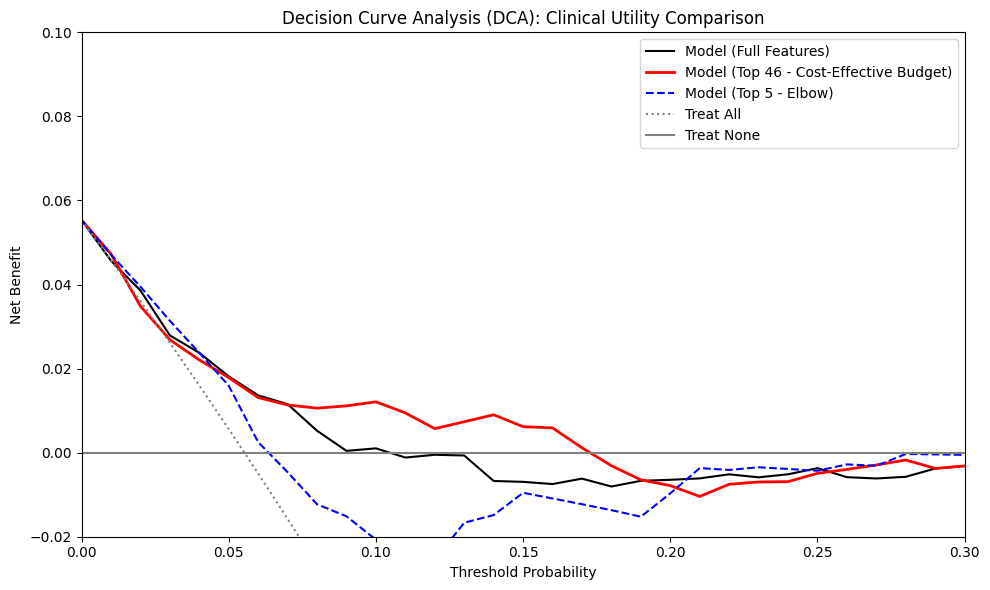


💡 ข้อสังเกต: โมเดล 46 ตัวแปร ให้ Net Benefit เทียบเท่าโมเดล 53 ตัวแปรอย่างชัดเจน


In [8]:
thresholds = np.linspace(0, 0.3, 31)
def get_nb(k_features):
    sub_f = top_f[:k_features]
    p = best_model_obj.get_params()
    for skip in ['verbose', 'logging_level', 'cat_features']: p.pop(skip, None)
    m_dca = CatBoostClassifier(**p, verbose=0) if 'CatBoost' in best_key else XGBClassifier(**p)
    m_dca.fit(X_train_res[sub_f], y_train_res)
    probs = m_dca.predict_proba(X_test[sub_f])[:, 1]
    return [calculate_net_benefit(y_test, probs, t) for t in thresholds]

nb_full = [calculate_net_benefit(y_test, trained_models[best_key]['probs'], t) for t in thresholds]
nb_opt = get_nb(optimal_k)
nb_5 = get_nb(5)
nb_all = [calculate_net_benefit(y_test, np.ones(len(y_test)), t) for t in thresholds]
nb_none = [0] * len(thresholds)

dca_df = pd.DataFrame({'Threshold': thresholds, 'Net_Benefit_Full': nb_full, f'Net_Benefit_Top{optimal_k}': nb_opt, 'Net_Benefit_Top5': nb_5, 'Treat_All': nb_all, 'Treat_None': nb_none})
dca_df.to_excel('reports_2567/tables/DCA_Analysis_Summary.xlsx', index=False)

plt.figure(figsize=(10,6))
plt.plot(thresholds, nb_full, color='black', label='Model (Full Features)')
plt.plot(thresholds, nb_opt, color='red', linewidth=2, label=f'Model (Top {optimal_k} - Cost-Effective Budget)')
plt.plot(thresholds, nb_5, color='blue', linestyle='--', label='Model (Top 5 - Elbow)')
plt.plot(thresholds, nb_all, color='gray', linestyle=':', label='Treat All')
plt.plot(thresholds, nb_none, color='gray', label='Treat None')
plt.ylim(-0.02, 0.1); plt.xlim(0, 0.3); plt.xlabel('Threshold Probability'); plt.ylabel('Net Benefit')
plt.title('Decision Curve Analysis (DCA): Clinical Utility Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('reports_2567/figures/dca/DCA_Comparison.png')
plt.show()
print(f"\n💡 ข้อสังเกต: โมเดล {optimal_k} ตัวแปร ให้ Net Benefit เทียบเท่าโมเดล 53 ตัวแปรอย่างชัดเจน")